# Módulo 3: Data science, ejercício resuelto

## 1: Carga y limpieza de datos:

C:\Users\Emilio\AppData\Local\Temp\ipykernel_5280\4142257500.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['cut_int'] + color_columns + clarity_columns).agg({


  cut_int color_E color_F color_G color_H color_I color_J clarity_IF  \
                                                                       
0       1   False   False   False   False   False   False      False   
1       1   False   False   False   False   False   False      False   
2       1   False   False   False   False   False   False      False   
3       1   False   False   False   False   False   False      False   
4       1   False   False   False   False   False   False      False   

  clarity_SI1 clarity_SI2  ... clarity_VVS2    price                   \
                           ...                  mean      max     min   
0       False       False  ...        False  7383.00  15964.0  2491.0   
1       False       False  ...         True  3607.00  10562.0   772.0   
2       False       False  ...        False  4473.00  10752.0   875.0   
3       False       False  ...         True      NaN      NaN     NaN   
4       False       False  ...        False  4512.88  151

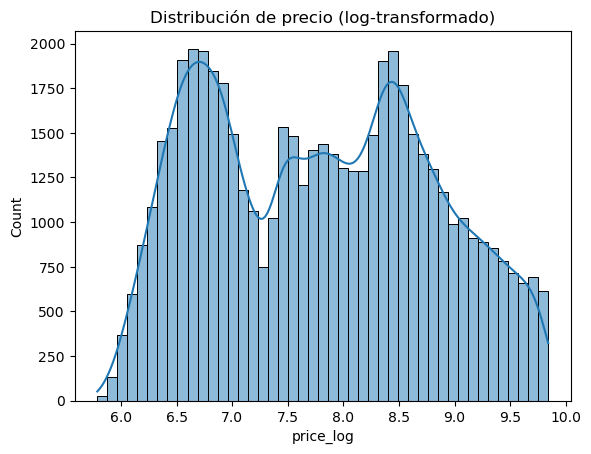

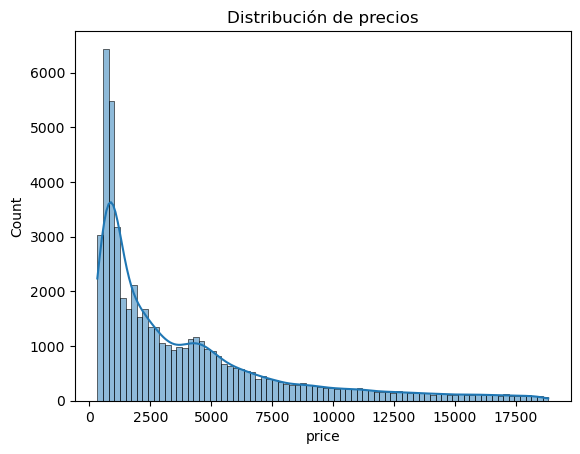

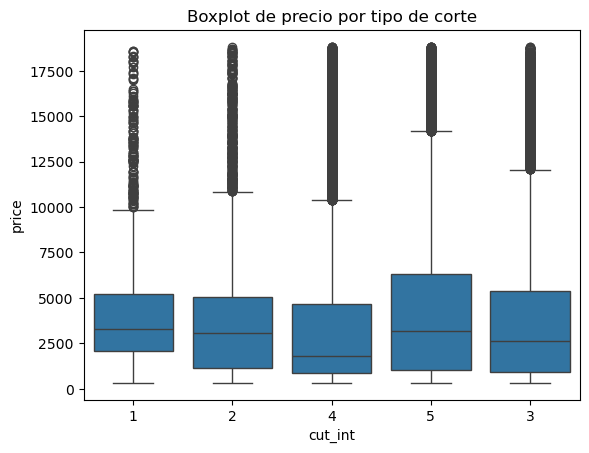

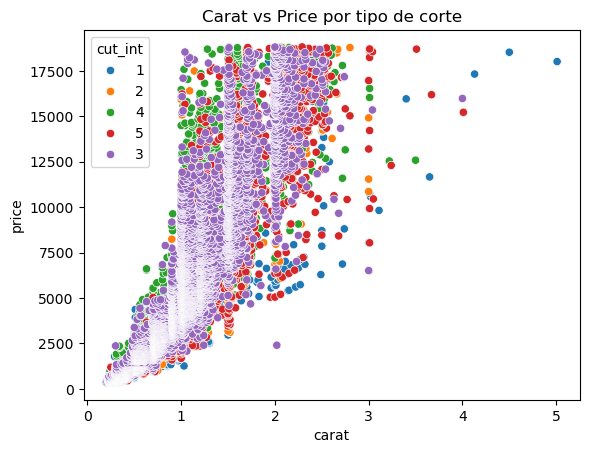

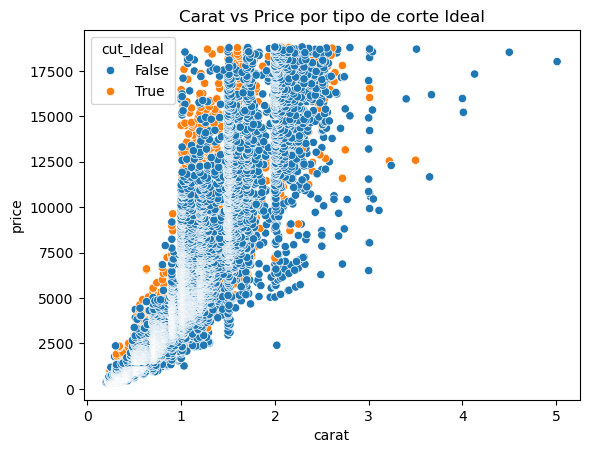

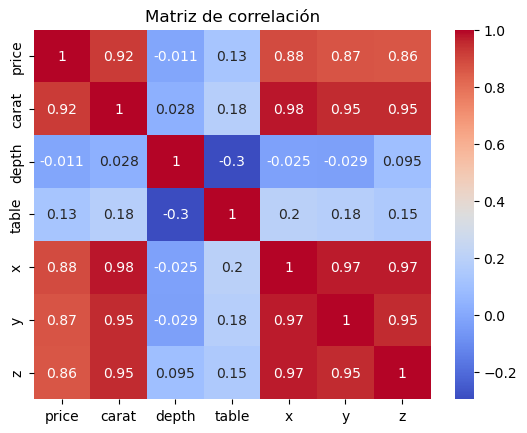

C:\Users\Emilio\AppData\Local\Temp\ipykernel_5280\4142257500.py:138: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(values='price', index='cut_int', columns=color_columns, aggfunc='mean')


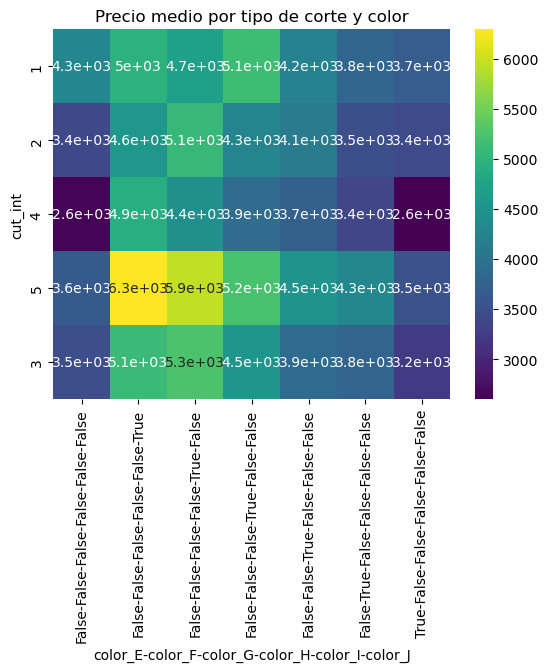

ValueError: could not convert string to float: 'Barato'

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Leer el archivo CSV
df = pd.read_csv('diamonds.csv')

# Parte 1: Carga y limpieza de datos

# Reemplazar valores '?' por valores nulos
df.replace('?', pd.NA, inplace=True)

# Convertir la columna 'carat' a tipo float32
df['carat'] = df['carat'].astype('float32')

# Convertir la columna 'cut' a tipo categoría
df['cut'] = df['cut'].astype('category')

# Convertir la columna 'price' a valores numéricos, ignorando errores y convirtiendo a NaN si es necesario
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Rellenar los valores nulos en 'price' con la mediana de la columna
df['price'] = df['price'].fillna(df['price'].median())

# Asegurarnos de que las columnas 'x', 'y', 'z' sean numéricas
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df['z'] = pd.to_numeric(df['z'], errors='coerce')

# Rellenar los valores nulos de 'x', 'y', 'z' con la media
df['x'] = df['x'].fillna(df['x'].mean())
df['y'] = df['y'].fillna(df['y'].mean())
df['z'] = df['z'].fillna(df['z'].mean())

# Llenar valores nulos en la columna 'cut' con el valor más frecuente (modo)
df['cut'] = df['cut'].fillna(df['cut'].mode()[0])

# Mapear los valores de la columna 'cut' a números antes de aplicar get_dummies
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Ideal': 4, 'Premium': 5}
df['cut_int'] = df['cut'].map(cut_map)

# Convertir las columnas categóricas en variables dummy (sin la columna 'cut' original)
df = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

# Parte 2: Transformaciones

# Crear columna 'price_iva' (precio + IVA 21%)
df['price_iva'] = df['price'] * 1.21

# Crear columna 'price_discount' con descuentos aplicados según las reglas
def apply_discount(row):
    if row['price'] < 1000 and row['cut_int'] == 4:  # Ideal = 4
        return row['price'] * 0.9  # 10% descuento
    elif 1000 <= row['price'] <= 5000 and row['cut_int'] == 3:  # Premium = 3
        return row['price'] * 0.85  # 15% descuento
    return row['price']  # No hay descuento

df['price_discount'] = df.apply(apply_discount, axis=1)

# Crear columna 'volume' (volumen = x * y * z)
df['volume'] = df['x'] * df['y'] * df['z']

# Ordenar por 'cut' y 'price'
df.sort_values(by=['cut_int', 'price'], ascending=[True, True], inplace=True)

# Filtrar columnas que contienen 'color' y 'clarity' en sus nombres
color_columns = [col for col in df.columns if 'color_' in col]
clarity_columns = [col for col in df.columns if 'clarity_' in col]

# Agrupar utilizando 'cut_int' y las columnas de 'color' y 'clarity' dinámicamente
grouped = df.groupby(['cut_int'] + color_columns + clarity_columns).agg({
    'price': ['mean', 'max', 'min'],
    'carat': ['mean', 'max', 'min'],
    'depth': ['mean', 'max', 'min']
}).reset_index()

# Ver el resultado
print(grouped.head())

# Parte 3: Distribuciones y transformaciones adicionales

# Visualización de outliers para 'price' usando Tukey's method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_filtered = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit)]

# Asimetría y curtosis
print(f"Asimetría de price: {df['price'].skew()}")
print(f"Curtosis de price: {df['price'].kurt()}")

# Transformar la columna 'price' con logaritmo
df['price_log'] = np.log(df['price'])

# Visualizar el histograma de 'price_log'
sns.histplot(df['price_log'], kde=True)
plt.title('Distribución de precio (log-transformado)')
plt.show()

# Discretizar la columna 'price' en tres categorías
price_bins = [0, 1000, 5000, float('inf')]
price_labels = ['Barato', 'Medio', 'Caro']
df['price_category'] = pd.cut(df['price'], bins=price_bins, labels=price_labels)

# Parte 4: Visualizaciones

# Histograma y KDE para la columna 'price'
sns.histplot(df['price'], kde=True)
plt.title('Distribución de precios')
plt.show()

# Boxplot para la columna 'price' por tipo de corte
sns.boxplot(x='cut_int', y='price', data=df)
plt.title('Boxplot de precio por tipo de corte')
plt.show()

# Scatterplot para 'carat' vs 'price' con color por 'cut'
sns.scatterplot(x='carat', y='price', hue='cut_int', data=df)
plt.title('Carat vs Price por tipo de corte')
plt.show()

# Si 'cut' fue convertida en columnas dummy, selecciona una de ellas (por ejemplo 'cut_Ideal')
sns.scatterplot(x='carat', y='price', hue='cut_Ideal', data=df)
plt.title('Carat vs Price por tipo de corte Ideal')
plt.show()

# Correlación entre variables numéricas
correlation = df[['price', 'carat', 'depth', 'table', 'x', 'y', 'z']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

# Pivot table y heatmap, usando las columnas generadas para 'color'
pivot_table = df.pivot_table(values='price', index='cut_int', columns=color_columns, aggfunc='mean')

# Visualización del heatmap
sns.heatmap(pivot_table, annot=True, cmap='viridis')
plt.title('Precio medio por tipo de corte y color')
plt.show()

# Gráfico de barras de correlación de 'price'
correlation_price = df.corr()['price'].drop('price')
sns.barplot(x=correlation_price.index, y=correlation_price.values)
plt.title('Correlación de variables con el precio')
plt.show()

## 2: Transformaciones

In [41]:
# Intentar convertir la columna 'price' a numérico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Verifica si hay valores nulos después de la conversión
print(df['price'].isnull().sum())
# Rellenar NaN con la mediana de la columna 'price'
df['price'] = df['price'].fillna(df['price'].median())
# Verifica las primeras filas de 'price' para detectar posibles problemas
print(df['price'].head())



0
0    326.0
1    326.0
2    327.0
3    334.0
4    335.0
Name: price, dtype: float64


## 3: Distribuciones

In [ ]:
# Visualización de outliers (columna price)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filtro de outliers
filtro_outliers = (df['price'] >= lower_limit) & (df['price'] <= upper_limit)
df_no_outliers = df[filtro_outliers]

# Asimetría, curtosis y transformación logarítmica
df['price_log'] = np.log(df['price'] + 1)  # Evita problemas con valores 0 o negativos

# Histograma y boxplot por tipo de corte
px.histogram(df, x='price_log', color='cut')
px.box(df, x='cut', y='price_log')

# Discretización de precios
bins = [0, 1000, 5000, df['price'].max()]
labels = ['Barato', 'Medio', 'Caro']
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels)

## 4: Visualizaciones

In [ ]:
# Univariantes: Histogramas y curvas de densidad
sns.histplot(df['carat'], kde=True)
sns.kdeplot(df['price'], shade=True)

# Boxplot
sns.boxplot(x='cut', y='price', data=df)

# Countplot
sns.countplot(x='cut', data=df)

# Bivariantes y multivariantes: Scatterplot
sns.scatterplot(x='carat', y='price', hue='cut', style='color', size='depth', data=df)

# Correlación con Pandas y visualización con Seaborn
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')

# Gráfico de barras para la columna 'price'
correlation_price = correlation['price'].sort_values(ascending=False)
correlation_price.plot(kind='bar')

# Pivot table y heatmap
pivot = df.pivot_table(index='cut', columns='color', values='price', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='viridis')

# Gráficas combinadas usando relplot
sns.relplot(x='carat', y='price', hue='cut', col='color', kind='scatter', data=df)


## Visualización de gráficos con Plotly

In [ ]:
# Histograma con Plotly
px.histogram(df, x='price', color='cut', nbins=50)

# Gráfico de dispersión 3D
px.scatter_3d(df, x='carat', y='price', z='depth', color='cut')

# Gráfico de líneas para precios agrupados por fecha simulada
df['date'] = pd.date_range(start='2023-01-01', periods=len(df))
df_sales = df.groupby('date', as_index=False)['price'].sum()
px.line(df_sales, x='date', y='price')
